Investigating feature attribution using SHAP from this link as the source of code:
https://towardsdatascience.com/using-shap-values-to-explain-how-your-machine-learning-model-works-732b3f40e137/

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [ ]:
import shap

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, confusion_matrix

In [ ]:
from sklearn.metrics import roc_auc_score, RocCurveDisplay

## DF task SHAP Values

In [ ]:
X_test = pd.read_csv('/content/drive/MyDrive/MySelfVersionProjects/datasets/large_scale_exps_data/df_data_and_outputs/aliras_vggish_test.csv')


In [ ]:
X_train2 = pd.read_csv('/content/drive/MyDrive/MySelfVersionProjects/datasets/large_scale_exps_data/df_data_and_outputs/aliras_vggish_train.csv')

In [ ]:
len(X_train2)

50224

In [ ]:
len(X_test)

611829

In [ ]:


X_train = X_train[:7000]
X_test = X_test[:7000]

In [ ]:
len(X_test)

7000

In [ ]:
y_test = pd.read_csv('/content/drive/MyDrive/MySelfVersionProjects/datasets/large_scale_exps_data/df_data_and_outputs/Df_eval_all_parts_numeric_labels.csv')

In [ ]:
y_test = y_test[:7000]

In [ ]:
y_test

,Label
0,1
1,1
2,1
3,1
4,1
...,...
6995,1
6996,1
6997,1
6998,1


In [ ]:
y_train = pd.read_csv('/content/drive/MyDrive/MySelfVersionProjects/datasets/large_scale_exps_data/df_data_and_outputs/DF_y_train_final_cleaned.csv')

In [ ]:
y_train

,Label
0,1.0
1,1.0
2,1.0
3,1.0
4,1.0
...,...
50219,1.0
50220,1.0
50221,1.0
50222,1.0


In [ ]:
y_train = y_train[:7000]

In [ ]:
# Apply SMOTE
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

In [ ]:
mlp = MLPClassifier(hidden_layer_sizes=(5,),  # very small network
                    activation='relu',
                    solver='adam',
                    alpha=0.001,
                    max_iter=500,
                    random_state=42)

In [ ]:



# Train model
mlp.fit(X_train_res, y_train_res)

MLPClassifier(alpha=0.001, hidden_layer_sizes=(5,), max_iter=500,
              random_state=42)

In [ ]:


# Evaluate
y_pred = mlp.predict(X_test)
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))


[[ 108  133]
 [ 783 5976]]
              precision    recall  f1-score   support

           0       0.12      0.45      0.19       241
           1       0.98      0.88      0.93      6759

    accuracy                           0.87      7000
   macro avg       0.55      0.67      0.56      7000
weighted avg       0.95      0.87      0.90      7000



In [ ]:
y_pred_prob = mlp.predict_proba(X_test)

In [ ]:
y_pred_proba = y_pred_proba

In [ ]:
y_pred_prob = y_pred_prob[:, 1]

IndexError: too many indices for array: array is 1-dimensional, but 2 were indexed

In [ ]:
roc_auc = roc_auc_score(y_test, y_pred_prob)
print(f"ROC AUC score: {roc_auc:.4f}")

ROC AUC score: 0.7398


In [ ]:
y_pred_prob_train = mlp.predict_proba(X_train)

In [ ]:
y_pred_prob_train = y_pred_prob_train[:, 1]

In [ ]:
roc_auc = roc_auc_score(y_train, y_pred_prob_train)
print(f"ROC AUC score: {roc_auc:.4f}")

ROC AUC score: 0.8091


In [ ]:
model = mlp

In [ ]:
model

MLPClassifier(alpha=0.001, hidden_layer_sizes=(5,), max_iter=500,
              random_state=42)

In [ ]:
# Fits the explainer
explainer = shap.Explainer(model.predict, X_test)
# Calculates the SHAP values - It takes some time
shap_values = explainer(X_test)

ExactExplainer explainer: 7001it [00:25, 202.24it/s]                          


In [ ]:
from scipy.special import softmax

def print_feature_importances_shap_values(shap_values, features):
    '''
    Prints the feature importances based on SHAP values in an ordered way
    shap_values -> The SHAP values calculated from a shap.Explainer object
    features -> The name of the features, on the order presented to the explainer
    '''
    # Calculates the feature importance (mean absolute shap value) for each feature
    importances = []
    for i in range(shap_values.values.shape[1]):
        importances.append(np.mean(np.abs(shap_values.values[:, i])))
    # Calculates the normalized version
    importances_norm = softmax(importances)
    # Organize the importances and columns in a dictionary
    feature_importances = {fea: imp for imp, fea in zip(importances, features)}
    feature_importances_norm = {fea: imp for imp, fea in zip(importances_norm, features)}
    # Sorts the dictionary
    feature_importances = {k: v for k, v in sorted(feature_importances.items(), key=lambda item: item[1], reverse = True)}
    feature_importances_norm= {k: v for k, v in sorted(feature_importances_norm.items(), key=lambda item: item[1], reverse = True)}
    # Prints the feature importances
    for k, v in feature_importances.items():
        print(f"{k} -> {v:.4f} (softmax = {feature_importances_norm[k]:.4f})")

In [ ]:
print_feature_importances_shap_values(shap_values, X_test.columns)

audio_quality -> 0.1220 (softmax = 0.3397)
breath -> 0.1193 (softmax = 0.3387)
pitch -> 0.0673 (softmax = 0.3216)


Interpretation

    All three features are contributing meaningfully to the model's decision — their normalized (softmax) importances are fairly close:

        Audio Quality is the most influential, responsible for about 34% of the total impact.

        Breath is just behind, also around 34%.

        Pitch is slightly less influential, contributing around 32%.

    The differences are small, which implies:

        The model is not overly reliant on any single feature.

        All three features are informative and relevant to the prediction task.

        The model is making relatively balanced use of the feature set.

        The first number (0.1220) is the mean absolute SHAP value: how much, on average, this feature shifts the model’s output.
        The second number is softmax importance:
        The softmax function takes a list of values (like SHAP importances) and rescales them to a probability-like distribution where:

    All values lie between 0 and 1

    The values sum to 1

It’s especially useful for interpreting relative importance — telling you how much each feature contributes compared to the others.

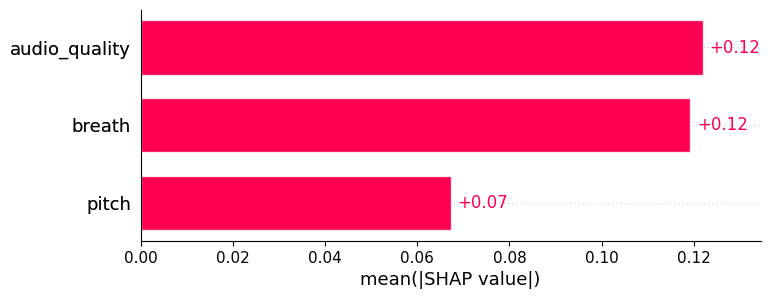

In [ ]:
#global effect analysis
shap.plots.bar(shap_values)

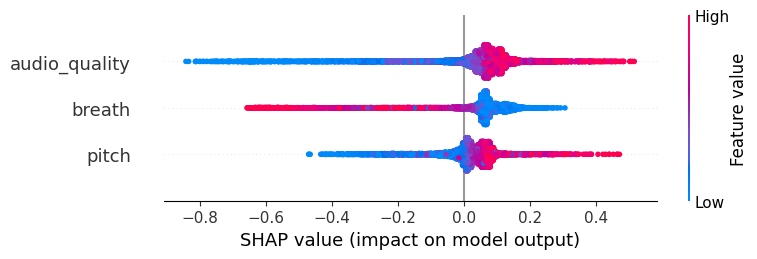

In [ ]:
shap.summary_plot(shap_values)

All the little dots on the plot represent a single observation. The horizontal axis represents the SHAP value, while the color of the point shows us if that observation has a higher or a lower value, when compared to other observations.

Local effect (for each observation) below

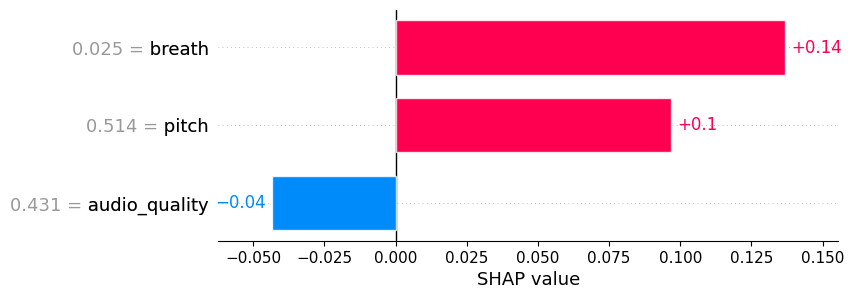

In [ ]:
#local effect analysis
shap.plots.bar(shap_values[0])

In [ ]:
shap_values[0]

.values =
array([-0.04333333,  0.09666667,  0.13666667])

.base_values =
np.float64(0.81)

.data =
array([0.43070045, 0.5139325 , 0.02461082])

above, .data = ... input features, 0.43 for audio quality, 0.51 for breath, 0.02 for anomalous pitch. base values are: This is the expected model output (i.e., the average prediction across the training data) before seeing any features.In classification, this typically refers to the model’s baseline logit or initial prediction probability.

----- Before using the specific features, the model would have predicted ~0.81 for this class.-----


These are the SHAP values — the individual contributions of each feature to changing the model output from the baseline:
Feature	SHAP Value	Interpretation
audio_quality	-0.0433	Decreased the prediction slightly (negative contribution)
breath	+0.0967	Increased the prediction
pitch	+0.1367	Strongly increased the prediction

You can compute the final model prediction by:
final prediction=base_value+∑SHAP values
final prediction=base_value+∑SHAP values
0.81+(−0.0433+0.0967+0.1367)≈1.00
0.81+(−0.0433+0.0967+0.1367)≈1.00

⚠️ If your model outputs probabilities, then SHAP may be explaining the log-odds (logit), not the probability directly — and you'd need to apply the sigmoid:
sigmoid(1.00)≈0.73
sigmoid(1.00)≈0.73

So, the model initially predicted 0.81, but after seeing the input features, it adjusted upward to a final prediction of approximately 0.73–1.0 depending on your model's output scale.

In [ ]:
y_pred_prob[0]

np.float64(0.7021304754415929)

This plot shows us what are the main features affecting the prediction of a single observation, and the magnitude of the SHAP value for each feature.
here it means:

In [ ]:
len(shap_values)

7000

In [ ]:

np.save('/content/drive/MyDrive/MySelfVersionProjects/datasets/large_scale_exps_data/df_data_and_outputs/shap_values_df_test_7000.npy', shap_values.values)